In [47]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/maimunarahma/ai-ml/main/kMeans/datasets/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [48]:
!git clone https://github.com/maimunarahma/ai-ml

fatal: destination path 'ai-ml' already exists and is not an empty directory.


In [49]:
import pandas as pd

custom_data = pd.read_csv(
    "/content/ai-ml/kMeans/datasets/custom.csv"
)
custom_data.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,81
1,22,18,77
2,25,25,60
3,28,40,65
4,32,50,45


In [50]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]


In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [52]:
from sklearn.cluster import KMeans
wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

In [53]:
kmeans = KMeans(n_clusters=5, random_state=42)

kmeans.fit(X_scaled)

KMeans(n_clusters=5, random_state=42)

In [54]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [55]:
custom_scaled = scaler.transform(custom_data)

In [56]:
clusters = kmeans.predict(custom_scaled)

In [57]:
main_clusters = kmeans.predict(X_scaled)

In [58]:
custom_data["Cluster"] = clusters

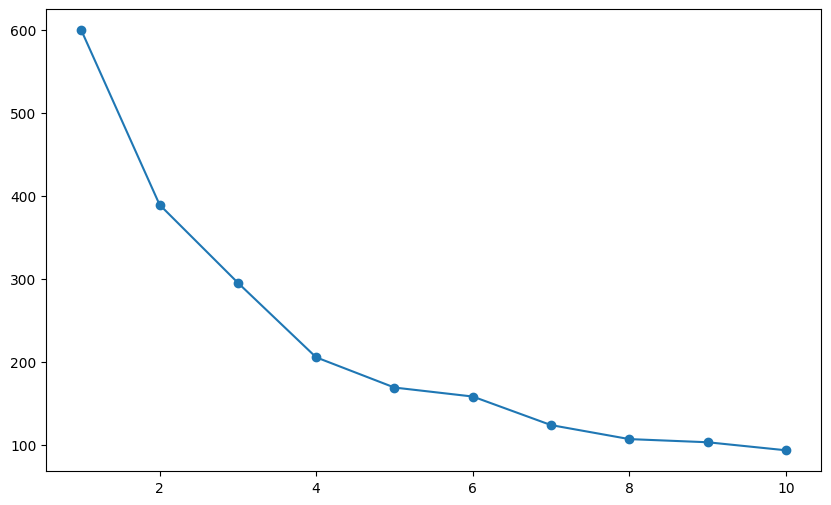

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1,11), wcss, marker='o')

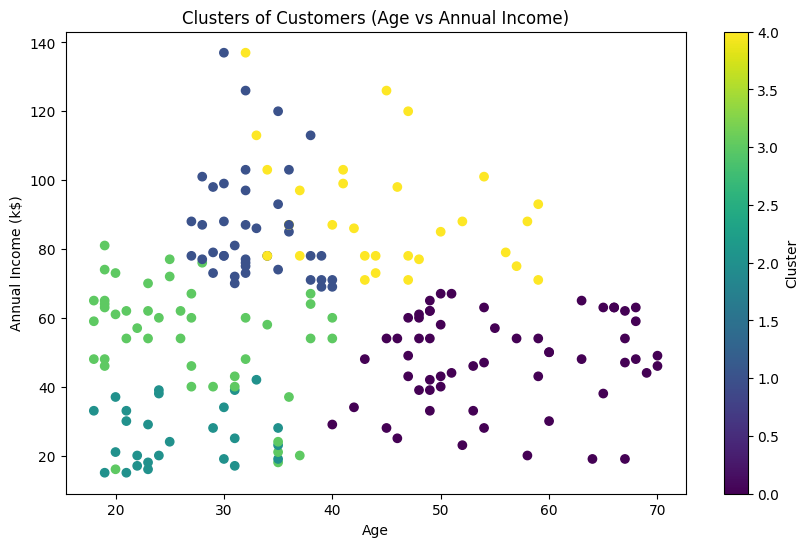

In [63]:
plt.figure(figsize=(10, 6))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=main_clusters)
plt.title('Clusters of Customers (Age vs Annual Income)')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.colorbar(label='Cluster')
plt.show()

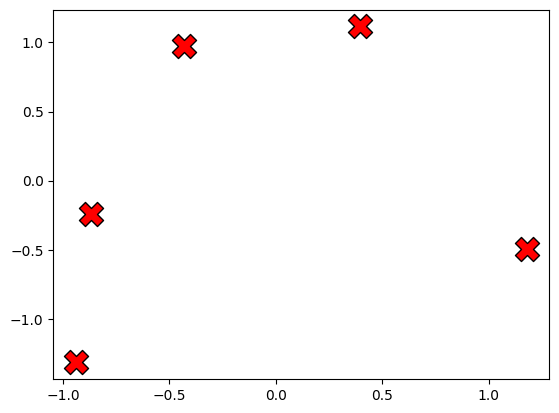

In [62]:
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='X',
    color='red',
    edgecolor='black'
)